<a href="https://colab.research.google.com/github/anandhapriya079/E-commerce/blob/main/Loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np

# Seed for reproducibility
np.random.seed(42)

# Configuration
n_users = 200
n_records = 1000

# Generate 200 unique User IDs
user_ids = [f"USR_{i:03d}" for i in range(1, n_users + 1)]

# Generate synthetic data
data = {
    'user_id': np.random.choice(user_ids, size=n_records),
    'loan_amount': np.random.randint(5000, 100001, size=n_records),
    'term_months': np.random.choice([12, 24, 36, 48, 60], size=n_records),
    'interest_rate': np.round(np.random.uniform(3.5, 18.5, size=n_records), 2),
    'credit_score': np.random.randint(300, 851, size=n_records),
    'income': np.random.randint(20000, 150001, size=n_records)
}

# Create DataFrame
df = pd.DataFrame(data)

# Determine loan status based on a simple heuristic (Credit Score and Income)
# to make the dummy dataset look more realistic
score_factor = df['credit_score'] / 850.0
income_factor = df['income'] / 150000.0
probability = (score_factor + income_factor) / 2.0

df['loan_status'] = np.where(probability > 0.45, 'Approved', 'Rejected')

# Display the DataFrame details and preview
print(f"Dataset Shape: {df.shape}")
print(f"Unique Users: {df['user_id'].nunique()}")
display(df.head())

# Save dataset to csv
df.to_csv('loan_dataset.csv', index=False)
print("\nDataset saved to 'loan_dataset.csv'")

Dataset Shape: (1000, 7)
Unique Users: 198


,user_id,loan_amount,term_months,interest_rate,credit_score,income,loan_status
0,USR_103,82735,48,18.10,793,63169,Approved
1,USR_180,86264,60,8.55,789,68287,Approved
2,USR_093,28275,48,7.95,372,74745,Approved
3,USR_015,77274,48,17.27,808,130168,Approved
4,USR_107,86449,48,5.16,689,133985,Approved



Dataset saved to 'loan_dataset.csv'


Model Accuracy: 0.9800

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      0.85      0.92        26
    Approved       0.98      1.00      0.99       174

    accuracy                           0.98       200
   macro avg       0.99      0.92      0.95       200
weighted avg       0.98      0.98      0.98       200



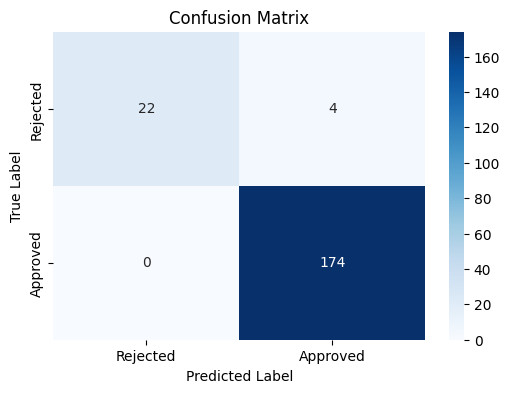

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare features and target variable
# We will use 'loan_amount', 'term_months', 'interest_rate', 'credit_score', and 'income' as features.
X = df[['loan_amount', 'term_months', 'interest_rate', 'credit_score', 'income']]
# Target variable is binary: 1 for Approved, 0 for Rejected
y = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

# 2. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardize features to improve Logistic Regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and fit the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

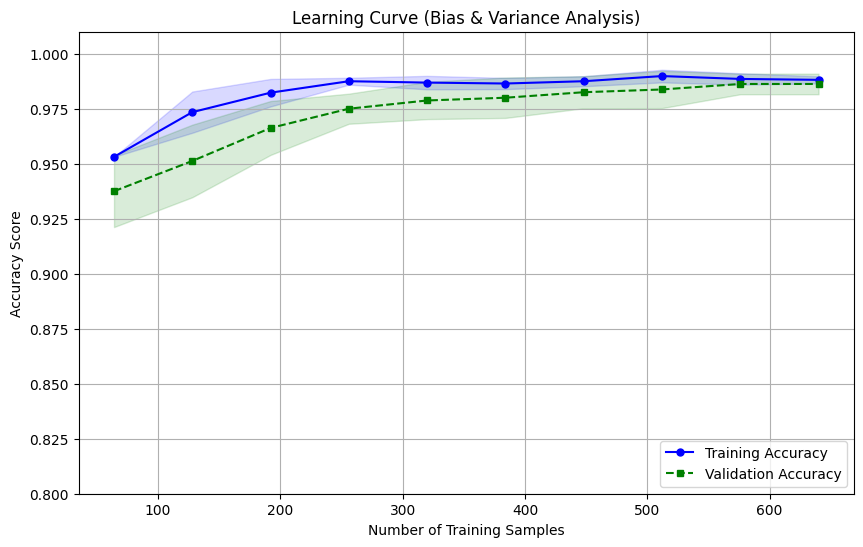

Final Training Accuracy: 0.9881
Final Validation Accuracy: 0.9863
Generalization Gap: 0.0019

Diagnostic: Low Bias & Low Variance. The model generalizes well and performs optimally.


In [12]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Calculate learning curve to evaluate bias and variance
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

# Calculate mean and standard deviation of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.title('Learning Curve (Bias & Variance Analysis)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.legend(loc='lower right')
plt.ylim(0.8, 1.01)
plt.show()

# Print diagnostic message based on the gap
final_train_acc = train_mean[-1]
final_val_acc = test_mean[-1]
gap = final_train_acc - final_val_acc

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Generalization Gap: {gap:.4f}")

if final_train_acc > 0.95 and gap < 0.03:
    print("\nDiagnostic: Low Bias & Low Variance. The model generalizes well and performs optimally.")
elif final_train_acc < 0.85:
    print("\nDiagnostic: High Bias (Underfitting). The model complexity is too low to capture the underlying pattern.")
elif gap > 0.05:
    print("\nDiagnostic: High Variance (Overfitting). The model fits the training data too closely and struggles to generalize.")

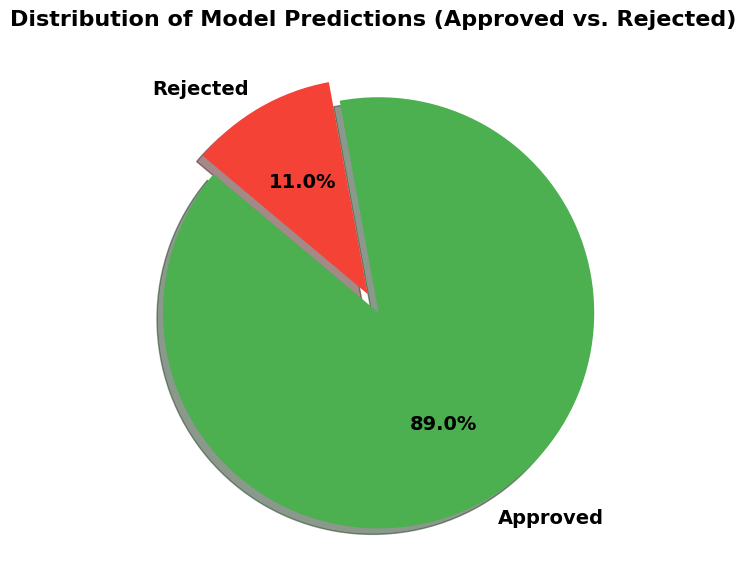

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Map predictions back to labels
predicted_labels = pd.Series(y_pred).map({1: 'Approved', 0: 'Rejected'})
prediction_counts = predicted_labels.value_counts()

# Plot Pie Chart
plt.figure(figsize=(7, 7))
colors = ['#4CAF50', '#F44336']
plt.pie(
    prediction_counts,
    labels=prediction_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 14, 'weight': 'bold'}
)

plt.title('Distribution of Model Predictions (Approved vs. Rejected)', fontsize=16, weight='bold')
plt.show()

### Test Model with Custom Input
Use the form fields on the right to input custom values and test the model's prediction.

In [29]:
#@title Loan Status Prediction Form { run: "auto" }
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Input fields
loan_amount = 25000 #@param {type:"number"}
term_months = 36 #@param [12, 24, 36, 48, 60] {type:"raw"}
interest_rate = 8.5 #@param {type:"number"}
credit_score = 391 #@param {type:"slider", min:300, max:850, step:1}
income = 100000 #@param {type:"number"}

# Ensure scaler and model are defined; if not, retrain them using the existing df
globals_dict = globals()
if 'scaler' not in globals_dict or 'model' not in globals_dict:
    print("Initializing and training model and scaler...")
    if 'df' not in globals_dict:
        # Check if the file exists on disk, otherwise regenerate it
        if not os.path.exists('loan_dataset.csv'):
            print("Dataset file not found. Regenerating synthetic dataset...")
            np.random.seed(42)
            n_users = 200
            n_records = 1000
            user_ids = [f"USR_{i:03d}" for i in range(1, n_users + 1)]
            data = {
                'user_id': np.random.choice(user_ids, size=n_records),
                'loan_amount': np.random.randint(5000, 100001, size=n_records),
                'term_months': np.random.choice([12, 24, 36, 48, 60], size=n_records),
                'interest_rate': np.round(np.random.uniform(3.5, 18.5, size=n_records), 2),
                'credit_score': np.random.randint(300, 851, size=n_records),
                'income': np.random.randint(20000, 150001, size=n_records)
            }
            df = pd.DataFrame(data)
            score_factor = df['credit_score'] / 850.0
            income_factor = df['income'] / 150000.0
            probability = (score_factor + income_factor) / 2.0
            df['loan_status'] = np.where(probability > 0.45, 'Approved', 'Rejected')
            df.to_csv('loan_dataset.csv', index=False)
            globals_dict['df'] = df
        else:
            df = pd.read_csv('loan_dataset.csv')
            globals_dict['df'] = df
    else:
        df = globals_dict['df']

    X = df[['loan_amount', 'term_months', 'interest_rate', 'credit_score', 'income']]
    y = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(random_state=42)
    model.fit(X_scaled, y)

    # Save to globals for subsequent runs
    globals_dict['scaler'] = scaler
    globals_dict['model'] = model

# Create a DataFrame for the custom input
custom_data = pd.DataFrame([{
    'loan_amount': loan_amount,
    'term_months': term_months,
    'interest_rate': interest_rate,
    'credit_score': credit_score,
    'income': income
}])

# Scale the input features using the pre-fitted scaler
custom_data_scaled = scaler.transform(custom_data)

# Make predictions
prediction = model.predict(custom_data_scaled)[0]
prediction_proba = model.predict_proba(custom_data_scaled)[0]

# Output results
status = "Approved" if prediction == 1 else "Rejected"
confidence = prediction_proba[prediction] * 100

print("\n=== Prediction Result ===")
print(f"Loan Status: {status}")
print(f"Confidence: {confidence:.2f}%")


=== Prediction Result ===
Loan Status: Approved
Confidence: 99.55%
